# Import and load

In [293]:
from langchain_openai import ChatOpenAI
from langchain_core.prompts import ChatPromptTemplate
from langchain.agents import create_agent
from langgraph.graph import StateGraph,MessagesState
from langchain_core.messages import HumanMessage, AIMessage
from langchain.tools import tool
from dotenv import load_dotenv
from langchain_community.utilities import SQLDatabase
from langchain_core.output_parsers import StrOutputParser
from langchain_community.vectorstores import FAISS
from langchain_openai.embeddings import OpenAIEmbeddings
from langgraph.checkpoint.memory import MemorySaver
from lingua import LanguageDetectorBuilder, Language
from typing import Optional

In [294]:
_ = load_dotenv()

In [295]:
llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)
embedding = OpenAIEmbeddings()
vectorstores = FAISS.load_local("review_faiss_db", embedding, allow_dangerous_deserialization = True)
memory = MemorySaver()

In [296]:
# output language detection
detector = LanguageDetectorBuilder.from_languages(
    Language.ENGLISH,
    Language.CHINESE,
    Language.PORTUGUESE,
    Language.FRENCH,
    Language.SPANISH,
    Language.GERMAN,
    Language.ITALIAN,
    Language.JAPANESE,
    Language.KOREAN
).build()

In [297]:
filler_key = {'payment_installments', 'customer_state', 'review_score',
    'product_category_name', 'seller_state', 'is_boleto', 'is_credit_card',
    'is_debit_card', 'is_not_defined', 'is_voucher'}
payment_map = {
    "credit_card":  "is_credit_card",
    "boleto":       "is_boleto",
    "debit_card":   "is_debit_card",
    "voucher":      "is_voucher",
    "not_defined":  "is_not_defined",
}

In [298]:
olist = SQLDatabase.from_uri("sqlite:///olist.db")

In [299]:
olist_raw_tables_schema = """
Database Schema (7 normalized tables):

1. orders (order_id PK, customer_id FK, order_status, order_purchase_timestamp)
2. customers (customer_id PK, customer_zip_code_prefix, customer_city, customer_state)
   - Note: customer_id is order-specific.
3. items (order_id FK, product_id FK, seller_id FK, price, freight_value)
4. products (product_id PK, product_category_name, product_weight_g)
5. sellers (seller_id PK, seller_zip_code_prefix, seller_city, seller_state)
6. payments (order_id FK, payment_type, payment_installments, payment_value)
7. reviews (order_id FK, review_score, review_comment_message)

JOIN RULES:
- orders JOIN customers ON orders.customer_id = customers.customer_id
- items JOIN orders ON items.order_id = orders.order_id
- items JOIN sellers ON items.seller_id = sellers.seller_id
- items JOIN products ON items.product_id = products.product_id
- payments JOIN orders ON payments.order_id = orders.order_id
- reviews JOIN orders ON reviews.order_id = orders.order_id
"""

In [300]:
customer_shopping_info_schema = """
### DEFAULT MAIN TABLE SCHEMA
Table Name: `customer_shopping_info`
Description: A comprehensive wide table containing flattened data for customers, orders, items, products, payments, reviews, and sellers. You should use THIS table by default for almost all queries.

Columns:
--- Customer Info ---
- customer_unique_id (TEXT): Unique identifier for a customer.
- customer_city (TEXT): City where the customer is located.
- customer_state (TEXT): State where the customer is located.
- customer_zip_code_prefix (TEXT): Zip code prefix of the customer.

--- Order & Timestamps Info ---
- order_id (TEXT): Unique identifier for the order.
- order_status (TEXT): Current status of the order (e.g., 'delivered', 'shipped', 'canceled').
- order_purchase_timestamp (DATETIME): Time when the order was placed.
- order_approved_at (DATETIME): Time when the payment was approved.
- order_delivered_carrier_date (DATETIME): Time when the order was handed to the logistics carrier.
- order_delivered_customer_date (DATETIME): Time when the actual delivery to the customer occurred.
- order_estimated_delivery_date (DATETIME): Originally estimated delivery date.
- recent_date (DATETIME): A fixed anchor date ('2018-11-12 00:00:00') representing the "current time" for this historical dataset. ALWAYS use this column instead of `CURRENT_DATE` or `date('now')` for time-based calculations like "recent X days".

--- Product & Item Info ---
- order_item_id (INTEGER): Sequential number identifying the item within the same order.
- product_id (TEXT): Unique identifier for the product.
- product_category_name (TEXT): Category of the product.
- product_weight_g (REAL): Weight of the product in grams.
- product_column_cm (REAL): A calculated metric (product_weight_g * product_height_cm * product_width_cm).
- price (REAL): Item-level product price. Use SUM(price) for product-category sales.
- freight_value (REAL): Freight/shipping fee for the item.

--- Payment & Review Info ---
- payment_type (TEXT): Method of payment (e.g., 'credit_card', 'boleto', 'voucher').
- payment_installments (INTEGER): Number of installments chosen by the customer.
- payment_sequential (INTEGER): Sequential indicator for multiple payment methods on a single order.
- payment_value (REAL): Order/payment-level transaction amount. May be duplicated across item rows in the wide table. Do not aggregate it by product_category_name for category sales; use price instead.
- review_score (INTEGER): Satisfaction score given by the customer (1 to 5).

--- Seller Info ---
- seller_id (TEXT): Unique identifier for the seller/merchant.
- seller_city (TEXT): City where the seller is located.
- seller_state (TEXT): State where the seller is located.
"""

In [301]:
important_limit = """
### 1. ENTITY DEDUPLICATION RULE
This is a wide item-level table, so order/payment-level fields may repeat.

- Counts:
  Use COUNT(DISTINCT order_id) for orders.
  Use COUNT(DISTINCT customer_unique_id) for customers.

- Product category sales:
  Use SUM(price).
  NEVER use SUM(payment_value) for product-category sales.

- Payment value by payment type:
  payment_value is payment-level and may repeat in the wide table.
  Before SUM(payment_value), de-duplicate by:
  DISTINCT order_id, payment_sequential, payment_type, payment_value.

Example:
SELECT payment_type, SUM(payment_value)
FROM (
  SELECT DISTINCT order_id, payment_sequential, payment_type, payment_value
  FROM customer_shopping_info
)
GROUP BY payment_type;

### 2. TIME CALCULATION RULE (SQLITE SYNTAX)
- This is a static dataset. NEVER use `date('now')`.
- ALWAYS use the `recent_date` column as the reference for "today".
- **Date Filtering**: For "last 30 days", use `WHERE order_purchase_timestamp >= date(recent_date, '-30 days')`.
- **Durations (e.g., delivery time)**: Directly subtract Julian days: `JULIANDAY(order_delivered_customer_date) - JULIANDAY(order_purchase_timestamp)`.

### 3. RANKING & AGGREGATION LIMITS
- For "Top N" problems within groups, use `DENSE_RANK() OVER (PARTITION BY ... ORDER BY ... DESC)`.
- Always return ONLY the Top 3 for each partitioned group.
- For all general exploration queries, append `LIMIT 10` unless the user requests specific total aggregates.

### 4. CATEGORY FILTERING (LANGUAGE MATCHING)
- Product category names are often in Portuguese (e.g., 'beleza_saude'). 
- If unsure of the exact full string, use `LIKE '%word%'` or apply the two-step mapping logic defined in the system prompt.

### 5. CATEGORY PRIORITIZATION / IMPROVEMENT QUERIES (STRICT TEMPLATE)
When asked to analyze product categories for improvement or prioritization, generate ONE single query returning multiple candidate categories. 

**MANDATORY COLUMNS:**
1. `product_category_name`
2. `COUNT(DISTINCT order_id) AS total_orders`
3. `SUM(price) AS total_sales` *(CRITICAL: Use SUM(price). NEVER use SUM(payment_value) for category sales)*
4. `AVG(review_score) AS average_review_score`
5. `COUNT(DISTINCT CASE WHEN review_score <= 2 THEN order_id END) AS low_rating_orders` *(CRITICAL: DO NOT label this as total_orders)*
6. `(CAST(COUNT(DISTINCT CASE WHEN review_score <= 2 THEN order_id END) AS FLOAT) / COUNT(DISTINCT order_id)) AS low_rating_rate`

**MANDATORY CLAUSES:**
- `HAVING COUNT(DISTINCT order_id) >= 100` *(To eliminate small-sample noise)*
"""

# Define a State

In [302]:
class ChatBotState(MessagesState):
    router: str | None = None
    output_language: str | None = None

# Language Detection node

In [303]:
language_detection_prompt = ChatPromptTemplate.from_messages([
    ("system", """
    Detect the user's requested final answer language.

    Return only one lowercase language name, e.g.:
    english, chinese, french, spanish, german, italian, portuguese, japanese, korean, arabic.

    If the user explicitly asks to answer in a language, return that language.
    Otherwise return the main language of the user's question.
    """),
    ("user", "{question}")
])
language_detection_chain = language_detection_prompt | llm | StrOutputParser()

In [304]:
def language_detection_node(ChatBotState) -> str:
    question = ChatBotState["messages"][-1].content
    return {"output_language":language_detection_chain.invoke({"question":question})}


# SQL Agent

In [305]:
def sql_execute(sql: str, db: SQLDatabase) -> str:
    return db.run(sql)

In [306]:
@tool
def sql_execute_tool(sql: str) -> str:
    """Execute SQL and return the query results."""
    try:
        return sql_execute(sql, olist)
    except Exception as e:
        return f"SQL Error: {e}. Please rewrite the SQL and try again."

In [307]:
@tool
def schema_tool() -> str:
    """Return the raw table structures."""
    return olist_raw_tables_schema

In [308]:
sql_agent = create_agent(
    llm,
    tools=[sql_execute_tool, schema_tool],
    system_prompt=f"""
You are an expert Data Analyst and SQL Agent.
Your goal is to answer the user's question by generating, executing, and summarizing SQLite queries.

### TABLE SCHEMA SECTION
{customer_shopping_info_schema}

### RULE: WHEN TO USE schema_tool
By default, rely on the customer_shopping_info schema above.
You MUST call schema_tool BEFORE writing SQL if:
1. The question requires raw tables not covered by the columns above.
2. Your SQL execution failed with "no such column" or "no such table".

### EXECUTION WORKFLOW
1. Analyze the question and map it to available fields.
2. If a category filter is needed, query distinct values first to map category names.
3. Execute the query using sql_execute_tool.
4. If execution fails, self-correct up to 3 attempts.
5. Return a natural language answer.

### OUTPUT STYLE
Choose the response length based on question complexity.

For simple metric questions, such as total count, total sales, average score, or top 1 result:
- Answer in 1 concise sentence.
- Do not add business interpretation unless the user asks for it.
- Do not repeat the same number.

For breakdown, ranking, comparison, trend, or multi-part questions:
- Use a short business-report style.
- Start with the direct answer.
- Then include a concise bullet list or explanation if useful.
- End with one objective business insight only if it is supported by the data.

### OUTPUT IMPORTANT RULES
- Never mention technical terms like "SQL", "database", "query", "code", or "execution results".
- Do not invent trends or business implications that are not directly supported by the data.
- Keep the answer proportional to the question.
- Your entire response must be in exactly one language: the language of the user's question.

### IMPORTANT CONSTRAINTS
{important_limit}

Input:
question: the user's question
"""
)

# RAG Agent

In [309]:
def payment_type_translate(filters):
    pt = filters.pop("payment_type", None)
    if not pt:
        return filters
    values = pt if isinstance(pt, list) else [pt]
    if len(values) == 1:
        filters[payment_map[values[0]]] = 1
    else:
        filters["$or"] = [{payment_map[v]: 1} for v in values]
    return filters

In [310]:
def clean_filter(filters: Optional[dict]) -> Optional[dict]:
    if not filters:
        return None
    cleaned = {k:v for k, v in filters.items() if k in filler_key or k.startswith('$')}
    return cleaned or None


In [311]:
def rag_execute(question:str, filters: Optional[dict] = None, k: int = 5) -> str:
    if filters:
        filters = payment_type_translate(filters)
        filters = clean_filter(filters)
    faiss_result = [i.page_content for i in vectorstores.similarity_search(question, k = 5, filter = filters,fetch_k = 200)]
    if not faiss_result and filters is not None:
        faiss_result = [i.page_content for i in vectorstores.similarity_search(question, k = 5, fetch_k = 20)]
    return faiss_result

In [312]:
@tool
def rag_execute_tool(question: str, filters: Optional[dict] = None) -> str:
    """Search reviews via FAISS similarity search with optional metadata filtering.

    Args:
        question: The user's natural-language query used for semantic similarity search.
        filters: Optional metadata filter dict. Omit when no structured field applies.
            Supported fields:
              - customer_state, seller_state: str (e.g. "SP"). Pass a list for OR (e.g. ["SP","RJ"]).
              - product_category_name: str. Pass a list for OR.
              - review_score: int 1-5. Use {"$lte": n} or {"$gte": n} for ranges.
              - payment_installments: int 1-24. Use {"$lte": n} or {"$gte": n} for ranges.
              - payment_type: one of "credit_card","boleto","debit_card","voucher","not_defined".
                Pass a list for OR.
            Examples:
              {"customer_state": "SP", "review_score": {"$lte": 2}}
              {"payment_type": ["credit_card", "voucher"]}

    Returns:
        A list of review texts matching the query (and filters, if provided).
    """
    return rag_execute(question, filters, k = 5)

In [313]:
filter_rag_prompt = """
    Available filter fields (only include if user explicitly mentions):
    - customer_state: Customer's state, e.g. "SP". Use list for OR: ["SP","RJ"].
    - seller_state: Seller's state, e.g. "SP". Use list for OR: ["SP","RJ"].
    - product_category_name: Product's category, e.g. "beleza_saude". Use list for OR.
    - review_score: int 1-5. Use $lte/$gte for ranges.
    - payment_installments: int 1-24. Use $lte/$gte for ranges.
    - payment_type: one of "credit_card","boleto","debit_card","voucher","not_defined". Use list for OR.
"""

In [314]:
rag_agent = create_agent(
llm,
tools=[rag_execute_tool],
system_prompt=f"""
  You are a RAG query assistant.
  Based on the user's question, retrieve relevant reviews via `rag_execute_tool` and return a concise summary.

  ### TOOL INPUT
    - question: the user's original question (always required)
    - filters: a dict of metadata filters (optional, omit if not applicable)

  ### FILTER FORMAT RULES
    1. Only include a field if the user EXPLICITLY mentions it. Do NOT use null, "", "any", or "all" as placeholders.
    2. Equals: `{{"customer_state": "SP"}}`
    3. OR (multi-value, same field): `{{"customer_state": ["SP", "RJ"]}}`
    4. Range: `{{"review_score": {{"$lte": 2}}}}`, `{{"payment_installments": {{"$gte": 6}}}}`
    5. Combined AND across fields (default): `{{"customer_state": "SP", "review_score": {{"$lte": 2}}}}`
    6. If no field applies, omit `filters` entirely.

  ### AVAILABLE FILTER FIELDS
    {filter_rag_prompt}
      
  ### EXAMPLES
    - "How do customers feel about delivery?" → `filters={{}}` (no structured field mentioned)
    - "2-star reviews in SP" → `filters={{"customer_state": "SP", "review_score": 2}}`
    - "Bad reviews (<=2 stars) from credit card or voucher users" →
    `filters={{"review_score": {{"$lte": 2}}, "payment_type": ["credit_card", "voucher"]}}`
    - "Reviews about beleza_saude category with 6+ installments" →
    `filters={{"product_category_name": "beleza_saude", "payment_installments": {{"$gte": 6}}}}`

  ### OUTPUT FORMAT (Natural Business Report Style)
    Your response must logically follow an invisible "Overview -> Details -> Conclusion" flow. 

    ### CRITICAL RULE: DO NOT print structural labels. 
      NEVER output words like "Overview:", "Paragraph 1:", "Details:", "The Feedback:", or "Conclusion:". Hide the structure using natural paragraph breaks (double newlines).

    ### Follow this paragraph structure strictly:
      - Paragraph 1: Summarize the overall emotional sentiment or the most central theme of the user feedback in one sentence. <MUST INSERT A BLANK LINE AFTER THIS PARAGRAPH>
      - Paragraph 2: Extract 3-4 specific core feedback points. Present these using clear Markdown bullet points. Each bullet MUST start on a new line. <MUST INSERT A BLANK LINE AFTER THIS PARAGRAPH>
      - Paragraph 3: Summarize these feedback points or provide a one-sentence business improvement suggestion.

    ### OUTPUT IMPORTANT RULES:
      NEVER mention technical terms like "RAG", "vector database", "semantic search", "document retrieval", or "system context".
      The final output must read as a single, polished, human-written business insight report without any rigid template headers. Adopt the tone of a Customer Experience Expert.

    ### ABSOLUTE LANGUAGE RULE: 
        Your ENTIRE response MUST be in exactly ONE language (the language of the user's question). 
        IF YOU QUOTE USER REVIEWS, YOU MUST TRANSLATE THE QUOTE. 
        WRONG: Customers said: "Produtos top."
        CORRECT: Customers said: "Top products."
        DO NOT leave any Portuguese or foreign words in your final output.
  """
)

# Business LLM Agent

In [315]:
olist_introduce = """
Olist is a Brazilian e-commerce company and marketplace platform that connects sellers, especially small and medium-sized businesses, with customers through online marketplaces. The public Olist dataset contains historical e-commerce transactions from this marketplace, including orders, customers, products, sellers, payments, deliveries, and reviews.
Use it to answer questions about sales, order volume, customer locations, product categories, payment methods, delivery performance, review scores, and customer complaints.
"""

In [316]:
llm_agent = create_agent(
    llm,
    tools=[],
    system_prompt=f"""
    You are a business overview assistant for the Olist e-commerce analytics chatbot.

    Your job is to answer questions about:
    - what this chatbot can do
    - what data it can analyze
    - what types of business questions it can answer
    - olist company information
    - previous conversation context if the user asks a memory-related question

    Use the following Olist dataset and chatbot information as your knowledge base:
    {olist_introduce}

    Rules:
    - Only answer questions related to this chatbot, the Olist dataset, or previous conversation context.
    - If the user asks what the chatbot can do, explain based on the Olist dataset information above.
    - If the user asks a memory-related question, answer based on the available conversation memory.
    - Keep the answer to one concise sentence.
    """
)

# Reject Answer node

In [317]:
def reject_answer_node(state):
    return {
        "messages": [
            AIMessage(content=(
                "Hi, I mainly help with questions related to the Olist e-commerce dataset, "
                "such as orders, sales, customers, product categories, payments, delivery performance, "
                "review scores, and customer complaints. "
                "You can try asking: 'Which state has the most orders?' or "
                "'What do customers complain about most?'"
            ))
        ]
    }

# Hybrid Agent

In [318]:
hybrid_agent = create_agent(
    llm,
    tools=[sql_execute_tool, rag_execute_tool, schema_tool],
    system_prompt = f"""
    You are an expert Hybrid AI Agent. You combine structured SQL analysis with unstructured RAG knowledge to provide deep business insights.

    ### DATA GROUNDING (Table Schema)
    {customer_shopping_info_schema}

    ### RULE: WHEN TO USE `schema_tool`
    By default, use the `customer_shopping_info` table. 
    You MUST call `schema_tool` BEFORE writing SQL if:
    1. You need columns not in the wide table (e.g., product dimensions).
    2. The user needs the absolute total count of orders/customers (wide table might have filtered some out due to INNER JOINs).
    3. SQL fails due to schema errors.

    ### HYBRID WORKFLOW (STRICT ORDER)

    **STEP 1: QUANTITATIVE FILTERING (SQL)**
    - You MUST use `sql_execute_tool` first to extract the "Target Set".
    - Example: If the question is about "2-star reviews", you MUST query the database to find which categories or states have the most 2-star reviews.
    - This step provides the **MANDATORY metadata filters** (e.g., category='beleza_saude', score=2) for the next step.

    **STEP 2: QUALITATIVE ANALYSIS (RAG)**
    Call `rag_execute_tool(question, filters)` with:
    - question: combine the user's original question with key findings from SQL.
    e.g., "Why do credit_card users in SP give 2-star reviews? SQL shows top categories: cama_mesa_banho (40%), beleza_saude (25%)."
    - filters: extract structured fields from SQL result and user question.

    {filter_rag_prompt}

    ### FILTER FORMAT
    - Equals: {{"customer_state": "SP"}}
    - OR (same field): {{"customer_state": ["SP", "RJ"]}}
    - Range: {{"review_score": {{"$lte": 2}}}}
    - Combined: {{"customer_state": "SP", "review_score": 2}}
    - Omit `filters` if no structured field applies.

    ### HYBRID EXAMPLE
    User: "Why do 2-star credit_card users complain?"
    STEP 1 SQL → top 2-star categories: ["cama_mesa_banho", "beleza_saude"]
    STEP 2 call:
        question = "Why do 2-star credit_card users complain? Top categories: cama_mesa_banho, beleza_saude"
        filters = {{"review_score": 2, "payment_type": "credit_card", "product_category_name": ["cama_mesa_banho", "beleza_saude"]}}

    **PHASE 3: Final Synthesis**
    - Integrate the "Numbers" (SQL) with the "Context" (RAG).
    - Return a cohesive, professional response. Don't just list data; explain what it means.

    ### EXECUTION GUARDRAIL
    - A Hybrid answer without SQL data is considered hallucination. 
    - If you attempt to call RAG before SQL, your internal reasoning will be flagged as "Invalid Logic".

    ### OUTPUT FORMAT (Natural Business Report Style)
        Your response must logically follow an invisible "Overview -> Data -> Feedback -> Conclusion" flow. 

        ### CRITICAL RULE: DO NOT print structural labels. 
        NEVER output words like "Overview:", "Paragraph 1:", "Details:", "The Data:", "The Transition:", "The Feedback:", or "Conclusion:". Hide the structure using natural paragraph breaks (double newlines).

        ### Follow this paragraph structure strictly:
        - Paragraph 1: Answer the core question directly in one sentence. Immediately follow up with the objective data facts, counts, or statistical distribution. <MUST INSERT A BLANK LINE AFTER THIS PARAGRAPH>
        - Paragraph 2: Use a natural conversational transition to connect the numbers to the underlying user feedback (e.g., "Behind these numbers, specific user reviews reveal..."). Then, list the actual user reviews or subjective opinions using clear Markdown bullet points. Each bullet MUST start on a new line. <MUST INSERT A BLANK LINE AFTER THIS PARAGRAPH>
        - Paragraph 3: Provide a final, insightful business conclusion combining both the quantitative data and the qualitative feedback in one sentence.

        ### OUTPUT IMPORTANT RULES:
        NEVER mention technical terms like "SQL", "RAG", "Hybrid", "vector search", or "database".
        The final output must read as a single, polished, human-written business insight report without any rigid template headers.
        
        ### ABSOLUTE LANGUAGE RULE: 
        Your ENTIRE response MUST be in exactly ONE language (the language of the user's question). 
        IF YOU QUOTE USER REVIEWS, YOU MUST TRANSLATE THE QUOTE. 
        WRONG: Customers said: "Produtos top."
        CORRECT: Customers said: "Top products."
        DO NOT leave any Portuguese or foreign words in your final output.
    
    ### IMPORTANT CONSTRAINTS
    {important_limit}

    Input:
    question: the user's question
"""
)

# Router

In [319]:
route_prompt = ChatPromptTemplate.from_messages([
    ("system", """You are a highly accurate routing classifier for an e-commerce database assistant. Your task is to route the user's query to one of four specific processing paths: 'sql', 'rag', 'hybrid', or 'llm'.

Strict definitions and rules:

1. 'sql' (Pure Quantitative & Structured Data):
   - Use this when the user asks for numbers, statistics, rankings, or specific data records.
   - Keywords: "how many", "total", "average", "top", "list of".
   - Rule: No subjective opinions or text analysis are required.

2. 'hybrid' (Structured Filter + Subjective Analysis) - [CRITICAL TO GET RIGHT]:
   - Use this when the user query contains SPECIFIC OBJECTIVE CONDITIONS (e.g., used installments, from a specific state, score is 1, specific dates) AND asks for SUBJECTIVE OPINIONS or text summaries.
   - Rationale: The system must first use SQL to accurately filter these specific users/orders, and then read their reviews.
   - Example 1: "What do users who paid with installments think?" -> hybrid (Filter: installments, Analysis: what they think)
   - Example 2: "Why are there so many 1-star reviews in SP state?" -> hybrid (Filter: 1-star + SP state, Analysis: why)

3. 'rag' (Pure Semantic Search for General Reviews):
   - Use this ONLY when the user asks broad questions about reviews or feelings WITHOUT specific structural database filters.
   - Example 1: "What are the general complaints about shipping?" -> rag
   - Example 2: "Do users like the product quality?" -> rag

4. 'llm'(Asking what can chatbot system do, or olist can do, or memory):
   - Use for business-related general questions, chatbot capability questions, memory questions, and simple greetings.
   - Examples: "What can you do?", "What is SQL in this project?", "What did we discuss before?"

5. 'reject'(non business problem):
   - Use for unrelated or useless requests that do not help with Olist, this chatbot, e-commerce analytics, data analysis, or memory.
   - Examples: "Tell me a joke.", "Hello!", "What is the capital of France?", "Write a poem."


IMPORTANT: You must output ONLY ONE WORD from this list: sql, rag, hybrid, reject, llm. No punctuation, no explanations.
"""),
    ("user", """Examples to guide you:
Query: "How many orders used more than 2 installments?"
Classification: sql

Query: "What are the common reviews about customer service?"
Classification: rag

Query: "What are the reviews like for users who used installments?"
Classification: hybrid

Query: "Summarize the reviews for orders delivered late."
Classification: hybrid

Query: "Can you explain the difference between a database and a vector store?"
Classification: reject

Query: "What is the capital of France?"
Classification: reject

Query: 'What can you do'
Classification: llm

Query: 'What is SQL in this project?'
Classification: llm 

Actual Query: {question}
Classification:""")
])

In [320]:
router_chain = route_prompt | llm | StrOutputParser()

In [321]:
def router_node(state: ChatBotState):
    router = router_chain.invoke({'question': state["messages"][-1].content})
    return {'router': router.lower().strip()}

# Translation Agent

In [322]:
translation_prompt = ChatPromptTemplate.from_messages([
    (
    'system',
    """
    Base on the translation_language_type,
    you must translate the message into the language in translation_language_type.
    """
    ),
    (
    'user',
    """
    translation_language_type: {translation_language_type}
    message: {message}
    """
    )
])

In [323]:
translation_chain = translation_prompt | llm | StrOutputParser()

In [324]:
def translation_node(state: ChatBotState):
    language = detector.detect_language_of(state["messages"][-1].content).name.lower()
    if state["output_language"] == language:
        return {"messages": [AIMessage(content=state["messages"][-1].content)]}
    else:
        translation_language_type = state["output_language"]
        message = state["messages"][-1].content
        translated = translation_chain.invoke({
            "translation_language_type": translation_language_type,
            "message": message
        })
        return {"messages": [AIMessage(content=translated)]}

# Langgraph

In [325]:
graph = StateGraph(ChatBotState)

In [326]:
graph.add_node("language_detection_node", language_detection_node)
graph.add_node("router_node", router_node)
graph.add_node("sql_agent", sql_agent)
graph.add_node("rag_agent", rag_agent)
graph.add_node("llm_agent", llm_agent)
graph.add_node("hybrid_agent", hybrid_agent)
graph.add_node("reject_answer_node", reject_answer_node)
graph.add_node("translation_node", translation_node)

graph.set_entry_point("language_detection_node")

graph.add_edge("language_detection_node", "router_node")
graph.add_conditional_edges(
    "router_node",
    lambda state: state["router"],
    {
        "sql": "sql_agent",
        "rag": "rag_agent",
        "hybrid": "hybrid_agent",
        "llm": "llm_agent",
        "reject": "reject_answer_node"
    }
)
graph.add_edge("sql_agent", "translation_node")
graph.add_edge("rag_agent", "translation_node")
graph.add_edge("hybrid_agent", "translation_node")
graph.add_edge("llm_agent", "translation_node")
graph.add_edge("reject_answer_node", "translation_node")

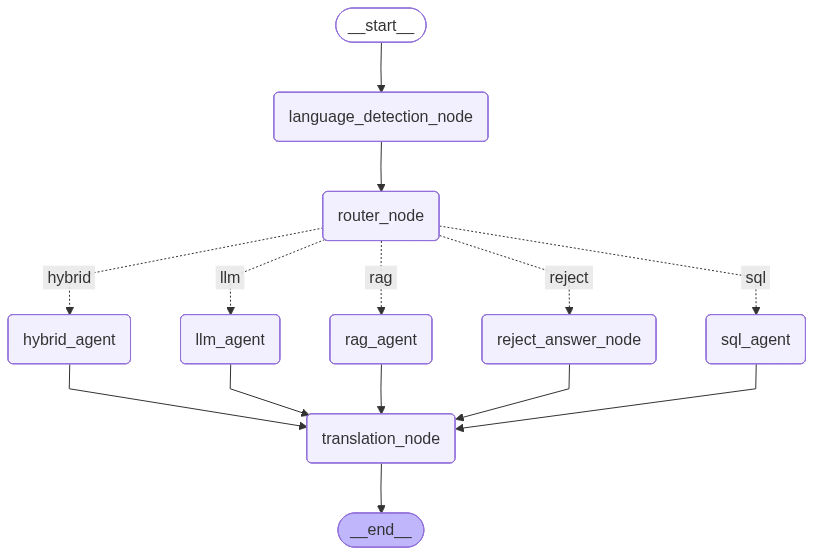

In [327]:
graph.compile(checkpointer=memory)

In [328]:
app = graph.compile()

In [355]:
app.invoke({'messages':HumanMessage('diga qual categoria de produto tem mais pedidos e quais são as reclamações mais comuns sobre ela.')})

{'messages': [HumanMessage(content='diga qual categoria de produto tem mais pedidos e quais são as reclamações mais comuns sobre ela.', additional_kwargs={}, response_metadata={}, id='40817b0c-8b6b-41fd-a9e5-e72734b1c8ca'),
  AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 52, 'prompt_tokens': 2743, 'total_tokens': 2795, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 2688}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_57133166c6', 'id': 'chatcmpl-DZw0kK34pz7ffXVpvckmadXFFXHeI', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019dd8af-1bb1-7181-9afa-cccd6d1e76d4-0', tool_calls=[{'name': 'sql_execute_tool', 'args': {'sql': 'SELECT product_category_name, COUNT(DISTINCT order_id) AS 